# **Signature verification: Verify signatures using geometric and texture features**

Primul pas in realizarea proiectului este sa importam librariile necesare.

In [ ]:
import cv2
import skimage
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.color import rgb2gray
from skimage.filters import gaussian

In cele ce urmeaza dorim sa afisam imaginile pe care le vom procesa ulterior.
Pentru aceasta mai intai vom selecta imaginile dorite folosind **upload()**.

In [ ]:
uploaded_pictures = files.upload()
file_names = list(uploaded_pictures.keys())

originals = file_names[:4]  # primele 4 fisiere sunt semnaturi autentice
fakes = file_names[4:] # urmatoarele 4 sunt semnaturi falsificate

Saving adev_1.png to adev_1.png
Saving adev_2.png to adev_2.png
Saving adev_3.png to adev_3.png
Saving adev_4.png to adev_4.png
Saving fals_1.png to fals_1.png
Saving fals_2.png to fals_2.png
Saving fals_3.png to fals_3.png
Saving adev_5.png to adev_5.png


Apoi "citim" imaginea din fisierul pe care l-am ales folosind functia imread si o transformam in gri folosind parametrul as_gray a carui valoare o setam la True.

In [ ]:
# Citim imaginile
original_images = [skimage.io.imread(name, as_gray = True) for name in originals]
fake_images = [skimage.io.imread(name,as_gray = True) for name in fakes]

Realizam o filtrare Gaussiana pentru a elimina zgomotul si a reduce detaliile fine. Parametrul sigma = 1 controleaza intensitatea estomparii, astfel avem o estompare moderata.

In [ ]:
# Filtrare Gaussiana a imaginilor
gaussian_originals = [gaussian(img, sigma=1) for img in original_images]
gaussian_fakes = [gaussian(img, sigma=1) for img in fake_images]

Pentru a simplifica analiza imaginilor realizam conversia in imag binare. Pragul de 0.5 inseamna ca orice pixel cu valoarea peste 0.5 e considerat ca face parte din semnatura, iar daca are valoarea mai mica de 0.5 se considera ca face parte din fundal.

In [ ]:
# Binarizare (semnatura = True, fundal = False)
binary_originals = [img > 0.5 for img in gaussian_originals]
binary_test = [img > 0.5 for img in gaussian_fakes]

Afisam cate o imagine din fiecare etapa a lantului de prelucrare: imaginea originala, in nuante de gri, filtrata Gaussian si binarizata.

Text(0.5, 1.0, 'Binarizat 1')

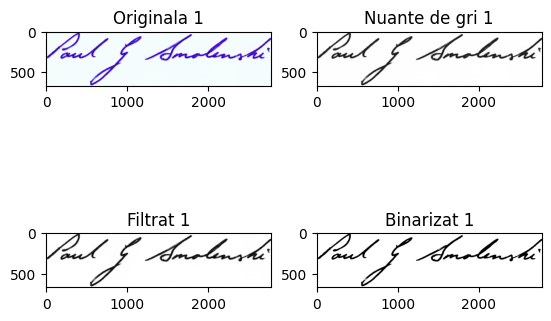

In [ ]:
# Afisare lant de prelucrare
plt.figure()
plt.subplot(2, 2, 1)
plt.imshow(skimage.io.imread(originals[0]), cmap='gray')
plt.title('Originala 1')

plt.subplot(2, 2, 2)
plt.imshow(original_images[0], cmap='gray')
plt.title('Nuante de gri 1')

plt.subplot(2, 2, 3)
plt.imshow(gaussian_originals[0], cmap='gray')
plt.title('Filtrat 1')

plt.subplot(2, 2, 4)
plt.imshow(binary_originals[0], cmap='gray')
plt.title('Binarizat 1')



Afisam setul de semnaturi de antrenare, format din 4 semnaturi autentice. Pentru aceasta folosim comenzile **figure()** si **imshow()**.

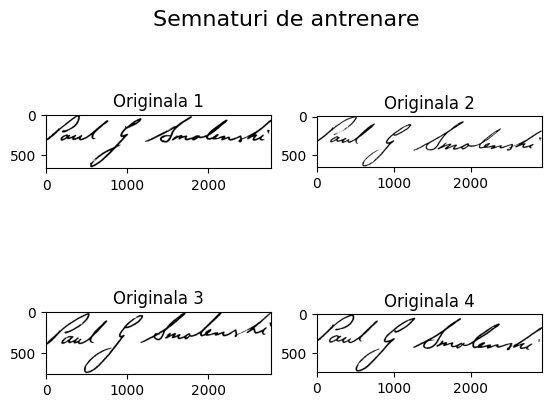

In [ ]:
# Afiseaza semnaturile de antrenare
plt.figure()
plt.subplot(2, 2, 1)
plt.imshow(binary_originals[0], cmap='gray')
plt.title('Originala 1')

plt.subplot(2, 2, 2)
plt.imshow(binary_originals[1], cmap='gray')
plt.title('Originala 2')

plt.subplot(2, 2, 3)
plt.imshow(binary_originals[2], cmap='gray')
plt.title('Originala 3')

plt.subplot(2, 2, 4)
plt.imshow(binary_originals[3], cmap='gray')
plt.title('Originala 4')

plt.suptitle('Semnaturi de antrenare', fontsize=16)
plt.show()



Afisam setul de semnaturi de test, format din 3 semnaturi falsificate si o semnatura autentica. Pentru aceasta folosim comenzile **figure()** si **imshow()**.

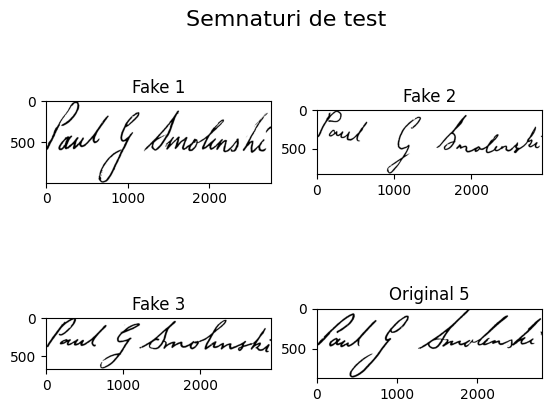

In [ ]:
# Afiseaza semnaturile de test
plt.figure()
plt.subplot(2, 2, 1)
plt.imshow(binary_test[0], cmap='gray')
plt.title('Fake 1')

plt.subplot(2, 2, 2)
plt.imshow(binary_test[1], cmap='gray')
plt.title('Fake 2')

plt.subplot(2, 2, 3)
plt.imshow(binary_test[2], cmap='gray')
plt.title('Fake 3')

plt.subplot(2, 2, 4)
plt.imshow(binary_test[3], cmap='gray')
plt.title('Original 5')

plt.suptitle('Semnaturi de test', fontsize=16)
plt.show()

Functia **Occupancy_Ratio** calculeaza raportul dintre nr pixelilor ocupati de semnatura si nr total de pixeli. In instructiunea **for** se calculeaza raportul de ocupare pentru fiecare imag. si afiseaza raportul minim si maxim de ocupare gasit in setul de imagini.

In [ ]:
def Occupancy_Ratio(image):
    height, width = image.shape # inaltimea si latimea imaginii binarizate
    total_pixels = height * width # nr. total de pixeli
    occupied_pixels = total_pixels - np.sum(image) # nr. pixeli ocupati (semnatura) = nr. total de pixeli - nr. pixeli albi (fundal)
    return occupied_pixels / total_pixels # raportul de ocupare (pixeli negri/total pixeli)

max_Occupancy_Ratio = 0 # presupunem ca nu exista raport de ocupare mai mic decat 0
min_Occupancy_Ratio = 1 # presupunem ca val maxima posibila a raportului de ocupare este 1

# raportul de ocupare min si max din setul de imagini
for image in binary_originals:
    Occupancy_Ratio_value = Occupancy_Ratio(image) # raportul de ocupare pentru imaginea curenta
    if Occupancy_Ratio_value > max_Occupancy_Ratio:
        max_Occupancy_Ratio = Occupancy_Ratio_value
    if Occupancy_Ratio_value < min_Occupancy_Ratio:
        min_Occupancy_Ratio = Occupancy_Ratio_value

print("Maxim Occupancy Ratio:", max_Occupancy_Ratio)
print("Minim Occupancy Ratio:", min_Occupancy_Ratio)


Maxim Occupancy Ratio: 0.07955688846097131
Minim Occupancy Ratio: 0.06292433968220562


Functia **Check_Occupancy_Ratio** clasifica pe baza occupancy ratio o imagine de test. Astfel daca imag. are valoarea raportului occupancy ratio in intervalul acceptat, atunci semnatura introdusa este autentica.

In [ ]:
def Check_Occupancy_Ratio(image, min_treshold, max_treshold):
    Occupancy_Ratio_value = Occupancy_Ratio(image) # calculeaza rata de ocupare
    # returneaza true daca valoarea ratei de ocupare este in interval si valoarea ratei de ocupare
    return [Occupancy_Ratio_value >= min_treshold and Occupancy_Ratio_value <= max_treshold, Occupancy_Ratio_value]

i = 1
for image in binary_test:
    OR = Check_Occupancy_Ratio(image, min_Occupancy_Ratio, max_Occupancy_Ratio)
    print("Poza " + str(i) + ": Raportul de ocupare: " + str(OR[1]))
    if OR[0]:
        print("Poza este autentica")
    else:
        print("Poza este falsa")
    i = i + 1

Poza 1: Raportul de ocupare: 0.07430677242680135
Poza este autentica
Poza 2: Raportul de ocupare: 0.05271937481814025
Poza este falsa
Poza 3: Raportul de ocupare: 0.08802314165280707
Poza este falsa
Poza 4: Raportul de ocupare: 0.06975221215727545
Poza este autentica


Calculam **raportul de densitate stanga/dreapta** impartind imaginea in doua zone egale (partea stanga si partea dreapta). Numarul pixelilor care apartin partii stangi este raportat la numarul pixelilor care apartin partii drepte a semnaturii. La final afisam cel mai mic si cel mai mare raport stanga/dreapta gasit in setul de imagini.

In [ ]:
max_OR_Ratio = 0 # presupunem ca nu exista raport de ocupare mai mic decat 0
min_OR_Ratio = 1 # presupunem ca val maxima posibila a raportului de ocupare este 1

for image in binary_originals:
  OR_left = Occupancy_Ratio(image[:, 0 : int(image.shape[1]/2)]) # luam in calcul toate randurile si coloanele de la 0 pana la jumatatea imag
  OR_right = Occupancy_Ratio(image[:, int(image.shape[1]/2) : image.shape[1]]) # toate randurile si coloanele ramase
  OR_ratio = OR_left/OR_right # calcul raport densitate stanga/dreapta

# calcul val min si max din setul de imagini
  if OR_ratio > max_OR_Ratio:
    max_OR_Ratio = OR_ratio
  if OR_ratio < min_OR_Ratio:
    min_OR_Ratio = OR_ratio

print("Maxim Occupancy Ratio:", max_OR_Ratio)
print("Minim Occupancy Ratio:", min_OR_Ratio)


Maxim Occupancy Ratio: 1.1892026117059349
Minim Occupancy Ratio: 0.9612003935716629


Clasificam pe baza raportului de densitate stanga/dreapta o imagine de test. Astfel daca imag. are valoarea raportului in intervalul acceptat, atunci semnatura introdusa este autentica.

In [ ]:
i = 1
# calcul raport densitate stanga/dreapta
for image in binary_test:
  OR_left = Occupancy_Ratio(image[:, 0 : int(image.shape[1]/2)])
  OR_right = Occupancy_Ratio(image[:, int(image.shape[1]/2) : image.shape[1]])
  OR_ratio = OR_left/OR_right

  print("Poza " + str(i) + ": raportul de densitate: " + str(OR_ratio))

  if OR_ratio >= min_OR_Ratio and OR_ratio <= max_OR_Ratio:
    print("Poza este autentica")
  else:
    print("Poza este falsa")

  i += 1

Poza 1: raportul de densitate: 1.0526747243299441
Poza este autentica
Poza 2: raportul de densitate: 0.8948351336411038
Poza este falsa
Poza 3: raportul de densitate: 0.9818004323268948
Poza este autentica
Poza 4: raportul de densitate: 1.0658324331541067
Poza este autentica


Functia **Critical_Points** detecteaza si numara colturile (punctele critice) dintr-o imagine folosing **algoritmul Harris**. Mai apoi calculam nr min si max de puncte critice din setul de imagini.

Minim Critical Points:  1402
Maxim Critical Points:  2253


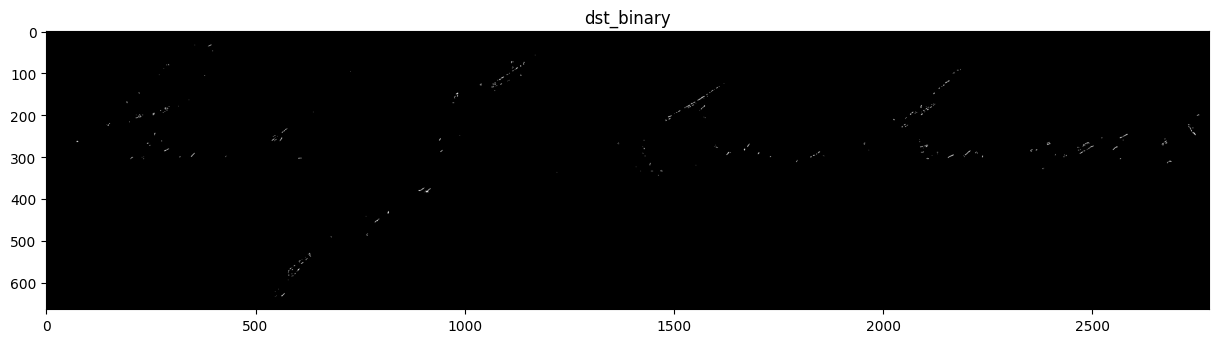

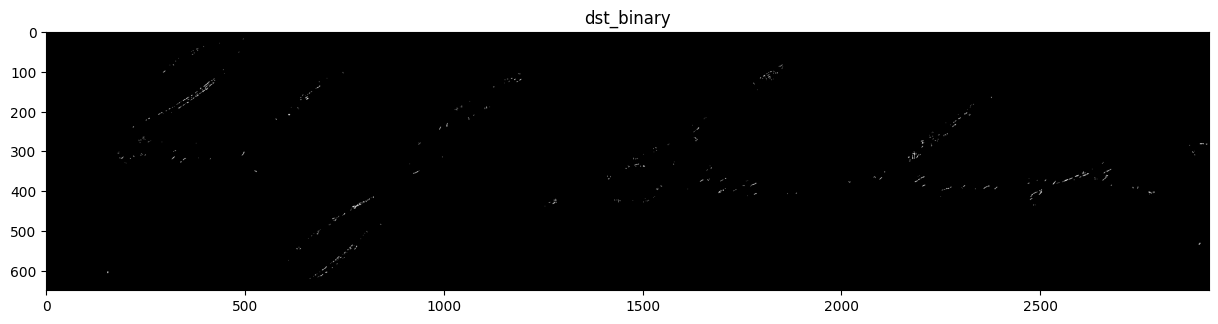

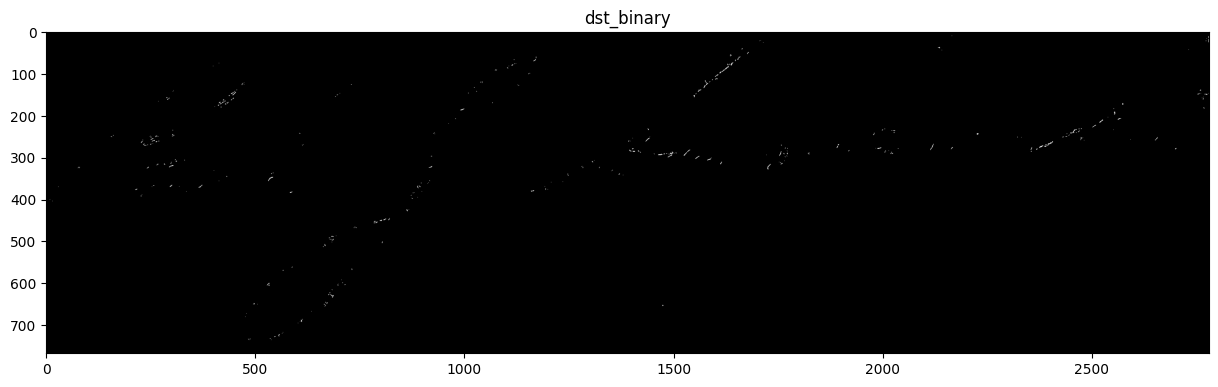

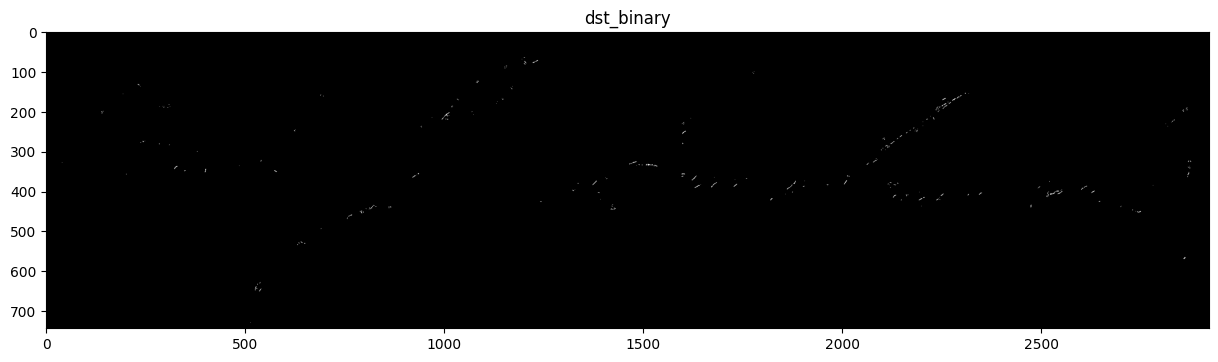

In [ ]:
def Critical_Points(image):

    # convertim imaginea in format float32 (cerinta pentru cornerHarris)
    img_float = np.float32(image)

    # aplicam detectorul de colturi Harris
    # img_float = imaginea in format float32 ; blockSize = dimensiunea blocului vecin
    # ksize = dimensiunea filtrului Sobel folosit pentru derivare ; k = param liber in ecuatia lui Harris
    dst = cv2.cornerHarris(img_float, blockSize=2, ksize=5, k=0.06)

    # binarizare unde pixelii pentru care alg Harris este mai mare decat 1% din max sunt considerati colturi (pixel alb)
    dst_binary = dst>0.01*dst.max()

    # numaram colturile
    num_corners = np.sum(dst_binary)

    # afisam imag binara cu colturile detectate
    plt.figure(figsize=(15, 10))
    plt.imshow(dst_binary, cmap='gray')
    plt.title('dst_binary')

    return int(num_corners) # nr total de pcte critice (colturi)

# raportul de ocupare min si max din setul de imagini
min_Critical = float('inf')
max_Critical = 0

for image in gaussian_originals:
    CP = Critical_Points(image)
    if CP < min_Critical:
        min_Critical = CP
    if CP > max_Critical:
        max_Critical = CP

print("Minim Critical Points: ", min_Critical)
print("Maxim Critical Points: ", max_Critical)




Folosind nr min si nr max de puncte critice, putem clasifica poza de test ca fiind autentica, daca se incadreaza in intervalul acceptat sau falsificata daca nu se incadreaza in acel interval.

Poza 1: nr. puncte critice: 3339
Poza este falsa
Poza 2: nr. puncte critice: 1323
Poza este falsa
Poza 3: nr. puncte critice: 1182
Poza este falsa
Poza 4: nr. puncte critice: 1549
Poza este autentica


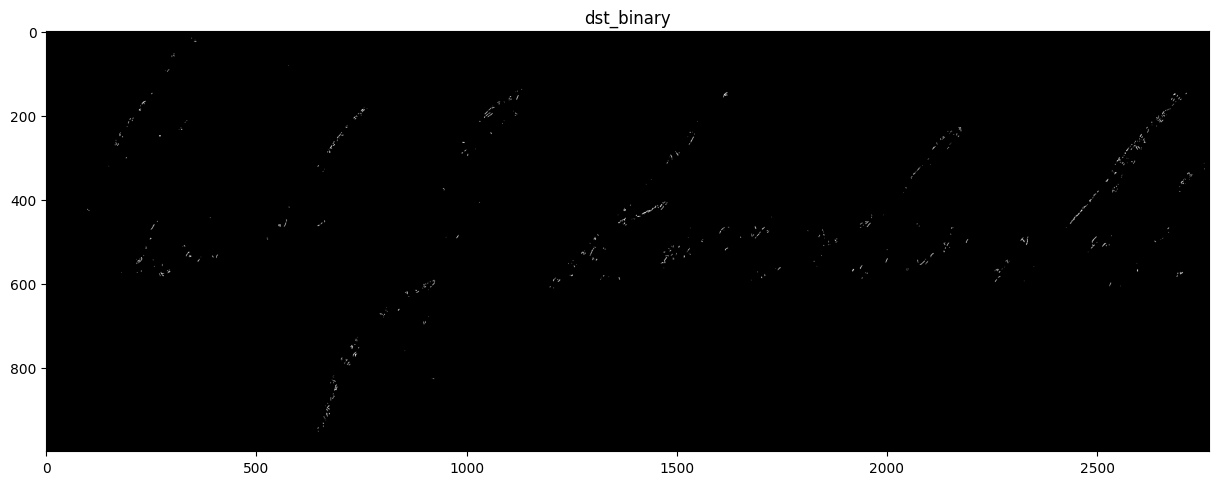

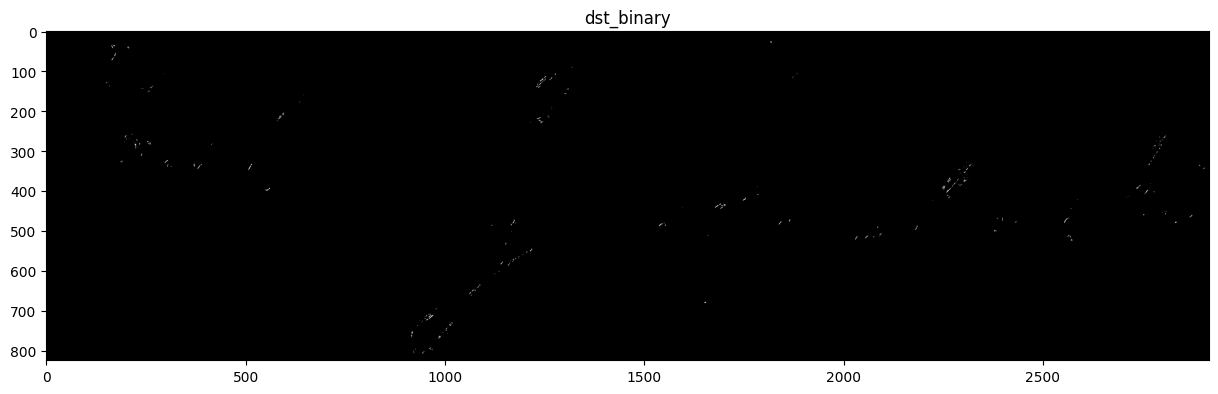

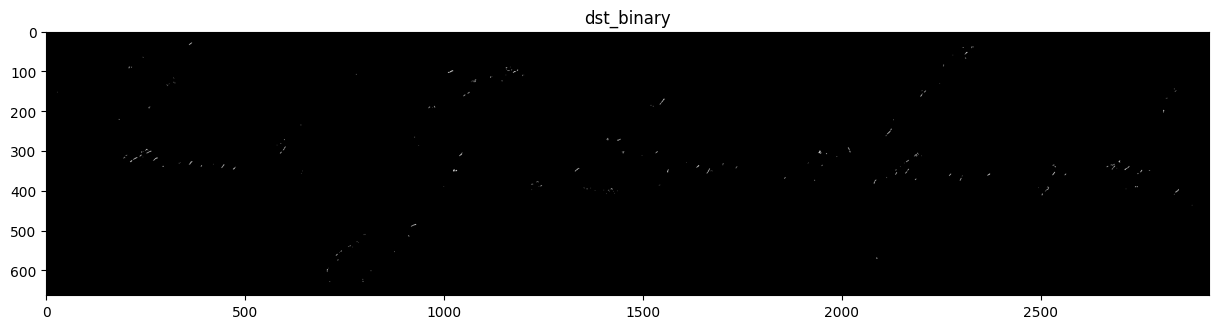

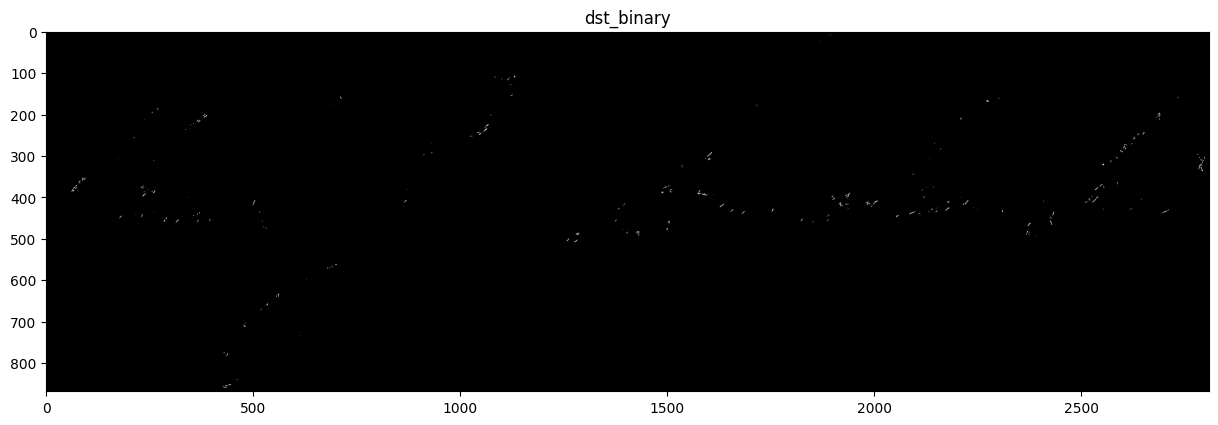

In [ ]:
# Verificăm imaginile de test
i = 1
for image in gaussian_fakes:
    CP = Critical_Points(image)
    print("Poza " + str(i) + ": nr. puncte critice: " + str(CP))
    if CP >= min_Critical and CP <= max_Critical:
        print("Poza este autentica")
    else:
        print("Poza este falsa")
    i += 1

Functia **Slope_COG** masoara inclinatia semnaturii, adica panta liniei care uneste centrul de greutate din stanga cu cel din dreapta. In acest mod putem identifica stiluri consistente sau diferente intre semnaturi. Afisam valoarea minima si maxima pentru aceasta inclinatie din intreg setul de imagini.

In [ ]:
def Slope_COG(image):
    h, w = image.shape # dimensiunile imag
    mid = w // 2 # mijlocul imag

    left_half = image[:, :mid] # toate liniile si coloanele pana la jumatate
    right_half = image[:, mid:] #toate liniile si restul coloanelor

    # coordonatele pixelilor activi
    coords_left = np.argwhere(left_half)
    coords_right = np.argwhere(right_half)

    # daca nu exista pixeli in vreuna din parti nu putem calcula panta
    if coords_left.size == 0 or coords_right.size == 0:
        return 0

    # calculam centrul de greutate in ambele parti
    cog_left = coords_left.mean(axis=0)
    cog_right = coords_right.mean(axis=0)

    # ajustam x pentru partea dreapta (pentru ca incepe de la mijlocul coloanelor)
    cog_right[1] += mid

    dy = cog_right[0] - cog_left[0] # diferenta pe verticala intre centrele de greutate
    dx = cog_right[1] - cog_left[1] # diferenta pe orizontala intre centrele de greutate

    slope = np.arctan2(dy, dx)  # panta în radiani

    return slope

# panta min si max din setul de imagini
min_slope = float('inf')
max_slope = float('-inf')

for image in binary_originals:
    slope = Slope_COG(image)
    if slope < min_slope:
        min_slope = slope
    if slope > max_slope:
        max_slope = slope

print("Minim slope:", min_slope)
print("Maxim slope:", max_slope)

Minim slope: -0.0022132470103749104
Maxim slope: 0.004545158758222649


Folosind valoarea minima si maxima pentru inclinatia semnaturii, putem clasifica poza de test ca fiind autentica, daca se incadreaza in intervalul acceptat sau falsificata daca nu se incadreaza in acel interval.

In [ ]:
# Verificăm imaginile de test
i = 1
for image in binary_test:
    slope = Slope_COG(image)
    print("Poza " + str(i) + ": panta: " + str(slope))
    if min_slope <= slope <= max_slope:
        print("Poza este autentica")
    else:
        print("Poza este falsa")
    i += 1

Poza 1: panta: 0.00011590285617428861
Poza este autentica
Poza 2: panta: -0.0029544971993597873
Poza este falsa
Poza 3: panta: -0.00116746194037479
Poza este autentica
Poza 4: panta: 0.0028034274430545894
Poza este autentica


Exportam proiectul in format html:

In [4]:
from google.colab import files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
%%shell
jupyter nbconvert --to html '/content/drive/MyDrive/Colab Notebooks/Proiect_TDAV.ipynb' --output='/content/Proiect_TDAV.html'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Proiect_TDAV.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 796174 bytes to /content/Proiect_TDAV.html


In [6]:
files.download('Proiect_TDAV.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>